In [2]:
"""
PyTorch port of Andrej Karpathy's char-rnn (Lua/Torch)
trained on the Complete Sherlock Holmes (data/cnus.txt)
"""
import torch
import torch.nn as nn
import numpy as np
import os, math, time

# Load text data 
data_dir = 'data'
input_file = os.path.join(data_dir, 'cnus.txt')

with open(input_file, 'r', encoding='utf-8') as f:
    text = f.read()

# Build vocabulary 
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode full text as integer tensor
data = np.array([char_to_idx[ch] for ch in text], dtype=np.int64)

print(f"Data has {len(data)} characters, {vocab_size} unique.")
print(f"Vocab: {''.join(chars)}")

Data has 3381928 characters, 97 unique.
Vocab: 
 !"&'()*,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]`abcdefghijklmnopqrstuvwxyz£°½ßàâèéêîñôöûü’


In [3]:
# ── Hyperparameters (matching char-rnn defaults) ──────────────────────
rnn_size    = 256     # hidden state size (char-rnn default 128, we use 256 for better quality)
num_layers  = 2       # number of LSTM layers
embedding_size = 64   # learned embedding dimension (torch-rnn wordvec_size default)
dropout     = 0.5     # dropout between LSTM layers
seq_length  = 50      # BPTT unroll length (char-rnn default)
batch_size  = 50      # batch size (char-rnn default)
max_epochs  = 30      # training epochs
learning_rate = 2e-3  # initial LR (char-rnn default)
lr_decay    = 0.97    # LR decay factor (char-rnn default)
lr_decay_after = 10   # start decaying after this epoch (char-rnn default)
grad_clip   = 5       # gradient clipping (char-rnn default)
train_frac  = 0.95    # fraction for training (char-rnn default)
val_frac    = 0.05    # fraction for validation (char-rnn default)
print_every = 50      # print loss every N iterations
eval_val_every = 1000 # evaluate validation every N iterations

device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Config: rnn_size={rnn_size}, embedding_size={embedding_size}, num_layers={num_layers}, dropout={dropout}")
print(f"        seq_length={seq_length}, batch_size={batch_size}, max_epochs={max_epochs}")

Using device: mps
Config: rnn_size=256, embedding_size=64, num_layers=2, dropout=0.5
        seq_length=50, batch_size=50, max_epochs=30


In [4]:
# ── Data batching ─────────
#  batches are sliced sequentially along axis 1.

class CharSplitLMMinibatchLoader:
    def __init__(self, data, batch_size, seq_length, train_frac, val_frac):
        self.batch_size = batch_size
        self.seq_length = seq_length

        n = len(data)
        # Trim data so it divides evenly into batches
        num_batches_total = n // (batch_size * seq_length)
        trimmed = num_batches_total * batch_size * seq_length
        data = data[:trimmed]

        # Reshape: each row is a contiguous stream
        # x = data, y = data shifted by 1
        xdata = data.copy()
        ydata = np.roll(data, -1)  # shift left by 1
        ydata[-1] = xdata[0]      # wrap around

        # Reshape into (batch_size, num_batches * seq_length)
        x_batches = xdata.reshape(batch_size, -1)
        y_batches = ydata.reshape(batch_size, -1)

        # Split into chunks of seq_length along axis 1
        self.nbatches = x_batches.shape[1] // seq_length
        self.x_batches = np.split(x_batches[:, :self.nbatches * seq_length], self.nbatches, axis=1)
        self.y_batches = np.split(y_batches[:, :self.nbatches * seq_length], self.nbatches, axis=1)

        # Train/val split by batch index
        ntrain = int(self.nbatches * train_frac)
        nval = int(self.nbatches * val_frac)
        # split_sizes[0] = train, [1] = val, [2] = test
        self.split_sizes = [ntrain, nval, self.nbatches - ntrain - nval]
        self.batch_ix = [0, 0, 0]

        print(f"Total batches: {self.nbatches} | Train: {ntrain}, Val: {nval}, Test: {self.split_sizes[2]}")
        print(f"Each batch: ({batch_size}, {seq_length})")

    def next_batch(self, split):
        """split: 0=train, 1=val, 2=test"""
        # Compute offset for this split
        offset = sum(self.split_sizes[:split])
        ix = self.batch_ix[split] + offset
        x = torch.tensor(self.x_batches[ix], dtype=torch.long)
        y = torch.tensor(self.y_batches[ix], dtype=torch.long)
        self.batch_ix[split] = (self.batch_ix[split] + 1) % self.split_sizes[split]
        return x, y

    def reset_batch_pointer(self, split):
        self.batch_ix[split] = 0

loader = CharSplitLMMinibatchLoader(data, batch_size, seq_length, train_frac, val_frac)

Total batches: 1352 | Train: 1284, Val: 67, Test: 1
Each batch: (50, 50)


In [5]:
# ── LSTM Model (matches char-rnn-master/model/LSTM.lua) ───────────────
# The original Lua char-rnn uses: OneHot → LSTM layers with dropout → Linear → LogSoftmax
# torch-rnn improves this with learned embeddings (nn.LookupTable) that map
# character indices to dense vectors of size embedding_size (wordvec_size),
# decoupled from the LSTM hidden state size (rnn_size).
# PyTorch's nn.Embedding is equivalent to Torch's nn.LookupTable.

class CharRNN(nn.Module):
    def __init__(self, vocab_size, embedding_size, rnn_size, num_layers, dropout):
        super(CharRNN, self).__init__()
        self.rnn_size = rnn_size
        self.num_layers = num_layers

        # remember_states: when True, the model carries hidden state across
        # forward() calls (equivalent to torch-rnn's self.remember_states).
        # State is detached automatically to truncate BPTT.
        self.remember_states = True
        self._h0 = None  # internal hidden state (h)
        self._c0 = None  # internal hidden state (c)

        # Learned embedding layer (torch-rnn's nn.LookupTable)
        # Maps character indices → dense vectors of size embedding_size.
        # Unlike char-rnn's OneHot (which produces sparse vocab_size-wide vectors),
        # this learns a compact representation during training.
        self.encoder = nn.Embedding(vocab_size, embedding_size)
        # LSTM: input is embedding_size (not rnn_size), output is rnn_size
        self.rnn = nn.LSTM(embedding_size, rnn_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.drop = nn.Dropout(dropout)
        # Output projection → vocab logits
        self.decoder = nn.Linear(rnn_size, vocab_size)

        self._init_weights()

    def _init_weights(self):
        # Initialize like char-rnn: uniform small weights
        initrange = 0.08
        self.encoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def reset_states(self):
        """Clear internal hidden state (like torch-rnn's resetStates())."""
        self._h0 = None
        self._c0 = None

    def forward(self, x, hidden=None):
        # x: (batch_size, seq_length)
        # If hidden is not explicitly passed, manage state internally
        if hidden is None:
            if self.remember_states and self._h0 is not None:
                # Reuse stored state, detached to truncate BPTT
                hidden = (self._h0.detach(), self._c0.detach())
            else:
                # Initialize zeros
                bsz = x.size(0)
                hidden = self.init_hidden(bsz, x.device)

        emb = self.drop(self.encoder(x))       # (batch, seq, embedding_size)
        output, hidden = self.rnn(emb, hidden)  # output: (batch, seq, rnn_size)
        output = self.drop(output)
        logits = self.decoder(output)            # (batch, seq, vocab_size)

        # Store state internally for next call
        self._h0 = hidden[0].detach()
        self._c0 = hidden[1].detach()

        return logits, hidden

    def init_hidden(self, bsz, device):
        # LSTM hidden = (h_0, c_0), each (num_layers, batch, rnn_size)
        h = torch.zeros(self.num_layers, bsz, self.rnn_size, device=device)
        c = torch.zeros(self.num_layers, bsz, self.rnn_size, device=device)
        return (h, c)

model = CharRNN(vocab_size, embedding_size, rnn_size, num_layers, dropout).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

CharRNN(
  (encoder): Embedding(97, 64)
  (rnn): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.5)
  (drop): Dropout(p=0.5, inplace=False)
  (decoder): Linear(in_features=256, out_features=97, bias=True)
)

Total parameters: 887,201


In [6]:
# ── Training loop (char-rnn-master/train.lua) ─────────────────
#   - RMSprop optimizer (alpha=0.95 maps to Lua decay_rate=0.95)
#   - Learning rate decay by lr_decay after lr_decay_after epochs
#   - Gradient clipping at grad_clip=5
#   - Hidden state carried across batches via remember_states 
#   - Validation loss evaluated every eval_val_every iterations

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, alpha=0.95)

train_losses = []
val_losses = []
iterations = 0
best_val_loss = float('inf')

# Checkpoint directory
os.makedirs('cv', exist_ok=True)

for epoch in range(1, max_epochs + 1):
    # Learning rate decay (matches Lua: after lr_decay_after epochs)
    if epoch > lr_decay_after:
        new_lr = learning_rate * (lr_decay ** (epoch - lr_decay_after))
        for param_group in optimizer.param_groups:
            param_group['lr'] = new_lr
        current_lr = new_lr
    else:
        current_lr = learning_rate

    loader.reset_batch_pointer(0)  # reset train
    model.reset_states()  # clear hidden state at epoch boundary
    epoch_loss = 0
    epoch_batches = 0
    t_start = time.time()

    model.train()
    for i in range(loader.split_sizes[0]):
        iterations += 1
        x, y = loader.next_batch(0)
        x, y = x.to(device), y.to(device)

        # Model manages hidden state internally (remember_states=True)
        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_batches += 1
        train_losses.append(loss.item())

        if iterations % print_every == 0:
            print(f"  iter {iterations} | train loss {loss.item():.4f}")

        # Validate periodically (matches Lua eval_val_every)
        if iterations % eval_val_every == 0:
            model.eval()
            val_loss_sum = 0
            model.reset_states()  # fresh state for validation
            loader.reset_batch_pointer(1)
            with torch.no_grad():
                for _ in range(loader.split_sizes[1]):
                    vx, vy = loader.next_batch(1)
                    vx, vy = vx.to(device), vy.to(device)
                    vlogits, _ = model(vx)
                    vloss = criterion(vlogits.reshape(-1, vocab_size), vy.reshape(-1))
                    val_loss_sum += vloss.item()
            avg_val = val_loss_sum / loader.split_sizes[1]
            val_losses.append((iterations, avg_val))
            print(f"  ** val loss = {avg_val:.4f} (iter {iterations})")

            # Save checkpoint if best val (matches Lua savefile logic)
            if avg_val < best_val_loss:
                best_val_loss = avg_val
                ckpt_path = f"cv/lm_lstm_epoch{epoch:.2f}_{avg_val:.4f}.pt"
                torch.save({
                    'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'vocab': char_to_idx,
                    'idx_to_char': idx_to_char,
                    'config': {'vocab_size': vocab_size, 'embedding_size': embedding_size,
                               'rnn_size': rnn_size,
                               'num_layers': num_layers, 'dropout': dropout},
                    'epoch': epoch, 'val_loss': avg_val
                }, ckpt_path)
                print(f"  ** saved checkpoint: {ckpt_path}")
            model.train()
            model.reset_states()  # fresh state after validation

    avg_epoch_loss = epoch_loss / epoch_batches
    elapsed = time.time() - t_start
    print(f"Epoch {epoch}/{max_epochs} | avg train loss: {avg_epoch_loss:.4f} | "
          f"lr: {current_lr:.6f} | time: {elapsed:.1f}s")

  iter 50 | train loss 2.9390
  iter 100 | train loss 2.5834
  iter 150 | train loss 2.2056
  iter 200 | train loss 2.1325
  iter 250 | train loss 2.0552
  iter 300 | train loss 2.0615
  iter 350 | train loss 2.0232
  iter 400 | train loss 1.9460
  iter 450 | train loss 1.8837
  iter 500 | train loss 1.8641
  iter 550 | train loss 1.8942
  iter 600 | train loss 1.7987
  iter 650 | train loss 1.8428
  iter 700 | train loss 1.7607
  iter 750 | train loss 1.7586
  iter 800 | train loss 1.7368
  iter 850 | train loss 1.7691
  iter 900 | train loss 1.8135
  iter 950 | train loss 1.7400
  iter 1000 | train loss 1.6509
  ** val loss = 1.6215 (iter 1000)
  ** saved checkpoint: cv/lm_lstm_epoch1.00_1.6215.pt
  iter 1050 | train loss 1.7199
  iter 1100 | train loss 1.6612
  iter 1150 | train loss 1.6962
  iter 1200 | train loss 1.6661
  iter 1250 | train loss 1.6883
Epoch 1/30 | avg train loss: 1.9426 | lr: 0.002000 | time: 22.4s
  iter 1300 | train loss 1.6461
  iter 1350 | train loss 1.6888
  

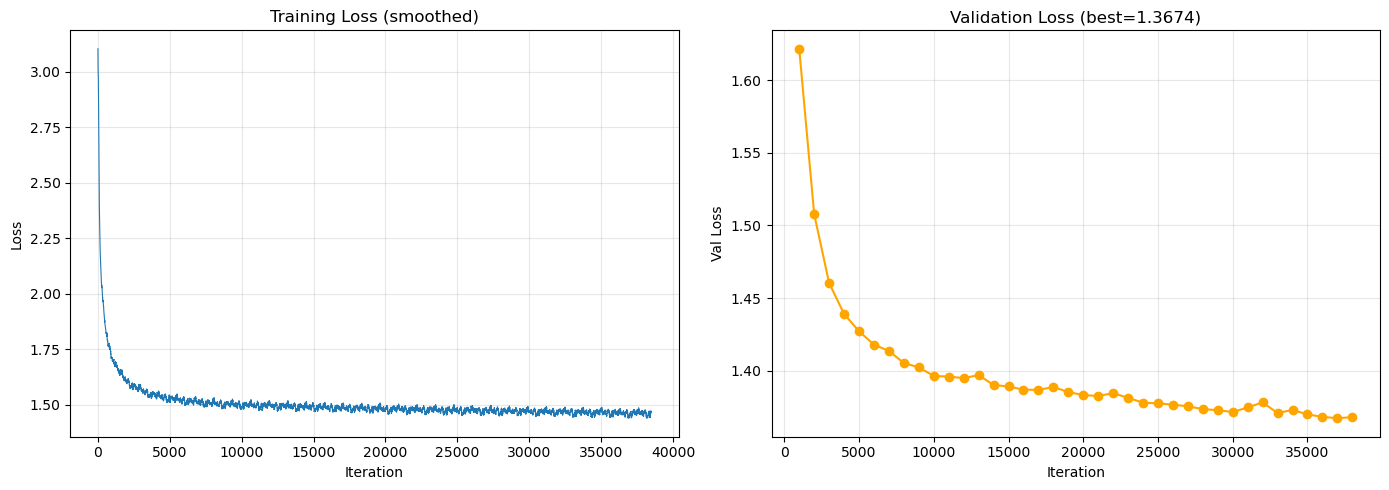

In [7]:
# ── Plot training & validation loss ───────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Smoothed training loss
window = 50
if len(train_losses) >= window:
    smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
    ax1.plot(smoothed, linewidth=0.8)
else:
    ax1.plot(train_losses, linewidth=0.8)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (smoothed)')
ax1.grid(True, alpha=0.3)

# Validation loss
if val_losses:
    val_iters, val_vals = zip(*val_losses)
    ax2.plot(val_iters, val_vals, 'o-', color='orange')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Val Loss')
    ax2.set_title(f'Validation Loss (best={best_val_loss:.4f})')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ── Text generation (matches char-rnn-master/sample.lua) ──────────────
# Ported from sample.lua: supports temperature, primetext, and sampling
# Added: seed parameter for reproducible generation (Lua uses torch.manualSeed)

def generate(model, prime_text="", length=2000, temperature=0.7, sample=True, seed=4869):
    """
    Generate text character by character.
    Args:
        prime_text: seed text to warm up hidden state (like -primetext in Lua)
        length: number of characters to generate (like -length in Lua)
        temperature: sampling temperature (like -temperature in Lua)
        sample: if True, sample from distribution; if False, argmax (like -sample in Lua)
        seed: random seed for reproducibility (like -seed in Lua, default 4869)
    """
    # Set seed for reproducible sampling (matches Lua: torch.manualSeed(opt.seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    model.eval()
    hidden = model.init_hidden(1, device)
    result = []

    # Prime the network with seed text (matches Lua primetext logic)
    if prime_text:
        result = list(prime_text)
        for ch in prime_text:
            x = torch.tensor([[char_to_idx[ch]]], dtype=torch.long, device=device)
            logits, hidden = model(x, hidden)

    # If no prime text, start with a random character
    if not prime_text:
        seed_idx = char_to_idx['\n']  # start with newline
        x = torch.tensor([[seed_idx]], dtype=torch.long, device=device)
        logits, hidden = model(x, hidden)
    else:
        # logits from last prime character already computed
        pass

    # Generate characters one by one
    with torch.no_grad():
        for _ in range(length):
            # Apply temperature (matches Lua: prediction:div(temperature))
            logits_scaled = logits[0, -1] / temperature

            if sample:
                probs = torch.softmax(logits_scaled, dim=0)
                next_idx = torch.multinomial(probs, 1).item()
            else:
                next_idx = logits_scaled.argmax().item()

            result.append(idx_to_char[next_idx])
            x = torch.tensor([[next_idx]], dtype=torch.long, device=device)
            logits, hidden = model(x, hidden)

    return ''.join(result)

# Generate samples at different temperatures
# seed=4869 for reproducibility; same seed → same output every time
for temp in [0.5, 0.7, 1.0]:
    print(f"\n{'='*70}")
    print(f"Temperature = {temp}  (seed=4869)")
    print('='*70)
    print(generate(model, prime_text="Sherlock Holmes ", length=1000, temperature=temp, seed=4869))


Temperature = 0.5  (seed=4869)
Sherlock Holmes to see
     which was conclusion to she and her window of a man that they was some
     three against the tacking seemed the confurt of the last sholter, and you have
     straight in a morning of the strange stands and the interest and
     scent that he had been the start which had been a look and some man would see the
     morning to the stands and had one of the street. It was not so proved the cholt
     of the great becon and a pretted and share and a grind and more and we have
     seen the death the servant companion of the complete which had some things
     and a morning which are the track and means that I had been a confidence would be
     has seen the room of the concoptrant shoulder showed the never course at a street profibess and
     the protice the morning and before the things and a considerable fare of
     the state of the point of the destrarition and brought of the confidence with
     the face of his papers of th

# Optimizer Comparison: RMSprop vs SGD (with momentum) vs Adam

We retrain the same LSTM architecture with each optimizer, using identical hyperparameters except for optimizer-specific settings. This lets us compare convergence speed, final loss, and generated text quality.

In [9]:
# ── Reusable training function for optimizer comparison ───────────────
# Same training loop as above, parameterized by optimizer.

def train_model(optimizer_name, num_epochs=30):
    """
    Train a fresh CharRNN with the given optimizer.
    Returns: (model, train_losses, val_losses, epoch_train_losses, epoch_val_losses)
    """
    # Fresh model with same architecture
    mdl = CharRNN(vocab_size, embedding_size, rnn_size, num_layers, dropout).to(device)

    # Set up optimizer
    if optimizer_name == 'RMSprop':
        opt = torch.optim.RMSprop(mdl.parameters(), lr=learning_rate, alpha=0.95)
    elif optimizer_name == 'SGD':
        # Mini-batch SGD with momentum (standard practice)
        opt = torch.optim.SGD(mdl.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_name == 'Adam':
        opt = torch.optim.Adam(mdl.parameters(), lr=learning_rate, betas=(0.9, 0.999))
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    crit = nn.CrossEntropyLoss()
    all_train_losses = []
    all_val_losses = []        # (iteration, val_loss)
    epoch_train_avg = []       # per-epoch average train loss
    epoch_val_avg = []         # per-epoch validation loss
    iters = 0
    base_lr = learning_rate

    print(f"\n{'='*70}")
    print(f"Training with {optimizer_name} for {num_epochs} epochs")
    print(f"{'='*70}")

    for epoch in range(1, num_epochs + 1):
        # LR decay after lr_decay_after epochs (same schedule for all)
        if epoch > lr_decay_after:
            new_lr = base_lr * (lr_decay ** (epoch - lr_decay_after))
            for pg in opt.param_groups:
                pg['lr'] = new_lr
            cur_lr = new_lr
        else:
            cur_lr = base_lr

        loader.reset_batch_pointer(0)
        mdl.reset_states()  # clear hidden state at epoch boundary
        epoch_loss = 0
        epoch_batches = 0
        t0 = time.time()

        mdl.train()
        for _ in range(loader.split_sizes[0]):
            iters += 1
            x, y = loader.next_batch(0)
            x, y = x.to(device), y.to(device)

            # Model manages hidden state internally (remember_states=True)
            logits, _ = mdl(x)
            loss = crit(logits.reshape(-1, vocab_size), y.reshape(-1))

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(), grad_clip)
            opt.step()

            epoch_loss += loss.item()
            epoch_batches += 1
            all_train_losses.append(loss.item())

            # Periodic validation
            if iters % eval_val_every == 0:
                mdl.eval()
                vl_sum = 0
                mdl.reset_states()  # fresh state for validation
                loader.reset_batch_pointer(1)
                with torch.no_grad():
                    for _ in range(loader.split_sizes[1]):
                        vx, vy = loader.next_batch(1)
                        vx, vy = vx.to(device), vy.to(device)
                        vout, _ = mdl(vx)
                        vl_sum += crit(vout.reshape(-1, vocab_size), vy.reshape(-1)).item()
                avg_vl = vl_sum / loader.split_sizes[1]
                all_val_losses.append((iters, avg_vl))
                mdl.train()
                mdl.reset_states()  # fresh state after validation

        avg_tl = epoch_loss / epoch_batches
        epoch_train_avg.append(avg_tl)

        # End-of-epoch validation
        mdl.eval()
        vl_sum = 0
        mdl.reset_states()  # fresh state for validation
        loader.reset_batch_pointer(1)
        with torch.no_grad():
            for _ in range(loader.split_sizes[1]):
                vx, vy = loader.next_batch(1)
                vx, vy = vx.to(device), vy.to(device)
                vout, _ = mdl(vx)
                vl_sum += crit(vout.reshape(-1, vocab_size), vy.reshape(-1)).item()
        avg_vl = vl_sum / loader.split_sizes[1]
        epoch_val_avg.append(avg_vl)

        elapsed = time.time() - t0
        print(f"  Epoch {epoch:2d}/{num_epochs} | train: {avg_tl:.4f} | val: {avg_vl:.4f} | "
              f"lr: {cur_lr:.6f} | {elapsed:.1f}s")

    return mdl, all_train_losses, all_val_losses, epoch_train_avg, epoch_val_avg

print("Training function defined. Ready to run comparisons.")

Training function defined. Ready to run comparisons.


In [10]:
# ── Save RMSprop results from earlier training ───────────────────────
# Repackage the results from the original RMSprop run (cells above)
# so we can compare them with SGD and Adam below.

rmsprop_model = model  # the model trained above
rmsprop_train_losses = train_losses
rmsprop_val_losses = val_losses

# Compute per-epoch averages from the original run
steps_per_epoch = loader.split_sizes[0]
rmsprop_epoch_train = []
for ep in range(max_epochs):
    start = ep * steps_per_epoch
    end = start + steps_per_epoch
    if end <= len(rmsprop_train_losses):
        rmsprop_epoch_train.append(np.mean(rmsprop_train_losses[start:end]))

# Per-epoch val: take the last val measurement in each epoch's iteration range
rmsprop_epoch_val = []
for ep in range(max_epochs):
    ep_end_iter = (ep + 1) * steps_per_epoch
    epoch_vals = [(it, vl) for it, vl in rmsprop_val_losses if it <= ep_end_iter]
    if epoch_vals:
        rmsprop_epoch_val.append(epoch_vals[-1][1])
    elif rmsprop_epoch_val:
        rmsprop_epoch_val.append(rmsprop_epoch_val[-1])  # carry forward

print(f"RMSprop: {len(rmsprop_epoch_train)} epoch train losses, {len(rmsprop_epoch_val)} epoch val losses")
print(f"  Final train loss: {rmsprop_epoch_train[-1]:.4f}" if rmsprop_epoch_train else "  (no data)")
print(f"  Best val loss:    {best_val_loss:.4f}")

RMSprop: 30 epoch train losses, 30 epoch val losses
  Final train loss: 1.4624
  Best val loss:    1.3674


In [11]:
# ── Train with Mini-batch SGD (with momentum) ────────────────────────
sgd_model, sgd_train, sgd_val, sgd_epoch_train, sgd_epoch_val = train_model('SGD', num_epochs=max_epochs)


Training with SGD for 30 epochs
  Epoch  1/30 | train: 3.3887 | val: 3.0016 | lr: 0.002000 | 22.4s
  Epoch  2/30 | train: 3.0182 | val: 2.9877 | lr: 0.002000 | 22.2s
  Epoch  3/30 | train: 3.0055 | val: 2.9842 | lr: 0.002000 | 22.8s
  Epoch  4/30 | train: 2.9997 | val: 2.9825 | lr: 0.002000 | 24.7s
  Epoch  5/30 | train: 2.9964 | val: 2.9815 | lr: 0.002000 | 22.6s
  Epoch  6/30 | train: 2.9939 | val: 2.9808 | lr: 0.002000 | 22.5s
  Epoch  7/30 | train: 2.9923 | val: 2.9803 | lr: 0.002000 | 22.6s
  Epoch  8/30 | train: 2.9911 | val: 2.9800 | lr: 0.002000 | 21.4s
  Epoch  9/30 | train: 2.9901 | val: 2.9797 | lr: 0.002000 | 21.6s
  Epoch 10/30 | train: 2.9894 | val: 2.9794 | lr: 0.002000 | 22.4s
  Epoch 11/30 | train: 2.9886 | val: 2.9792 | lr: 0.001940 | 22.2s
  Epoch 12/30 | train: 2.9882 | val: 2.9791 | lr: 0.001882 | 21.1s
  Epoch 13/30 | train: 2.9877 | val: 2.9789 | lr: 0.001825 | 21.2s
  Epoch 14/30 | train: 2.9874 | val: 2.9788 | lr: 0.001771 | 21.3s
  Epoch 15/30 | train: 2.9870

In [12]:
# ── Train with Adam ───────────────────────────────────────────────────
adam_model, adam_train, adam_val, adam_epoch_train, adam_epoch_val = train_model('Adam', num_epochs=max_epochs)


Training with Adam for 30 epochs
  Epoch  1/30 | train: 1.9908 | val: 1.6016 | lr: 0.002000 | 21.8s
  Epoch  2/30 | train: 1.6504 | val: 1.5038 | lr: 0.002000 | 22.1s
  Epoch  3/30 | train: 1.5883 | val: 1.4585 | lr: 0.002000 | 21.7s
  Epoch  4/30 | train: 1.5584 | val: 1.4406 | lr: 0.002000 | 22.5s
  Epoch  5/30 | train: 1.5415 | val: 1.4263 | lr: 0.002000 | 2649.8s
  Epoch  6/30 | train: 1.5306 | val: 1.4164 | lr: 0.002000 | 7441.7s
  Epoch  7/30 | train: 1.5241 | val: 1.4116 | lr: 0.002000 | 4517.2s
  Epoch  8/30 | train: 1.5183 | val: 1.4067 | lr: 0.002000 | 8173.2s
  Epoch  9/30 | train: 1.5134 | val: 1.4043 | lr: 0.002000 | 11130.8s
  Epoch 10/30 | train: 1.5110 | val: 1.4028 | lr: 0.002000 | 3952.8s
  Epoch 11/30 | train: 1.5084 | val: 1.3985 | lr: 0.001940 | 22.8s
  Epoch 12/30 | train: 1.5043 | val: 1.3957 | lr: 0.001882 | 25.4s
  Epoch 13/30 | train: 1.5014 | val: 1.3943 | lr: 0.001825 | 22.7s
  Epoch 14/30 | train: 1.5002 | val: 1.3927 | lr: 0.001771 | 21.4s
  Epoch 15/30 |

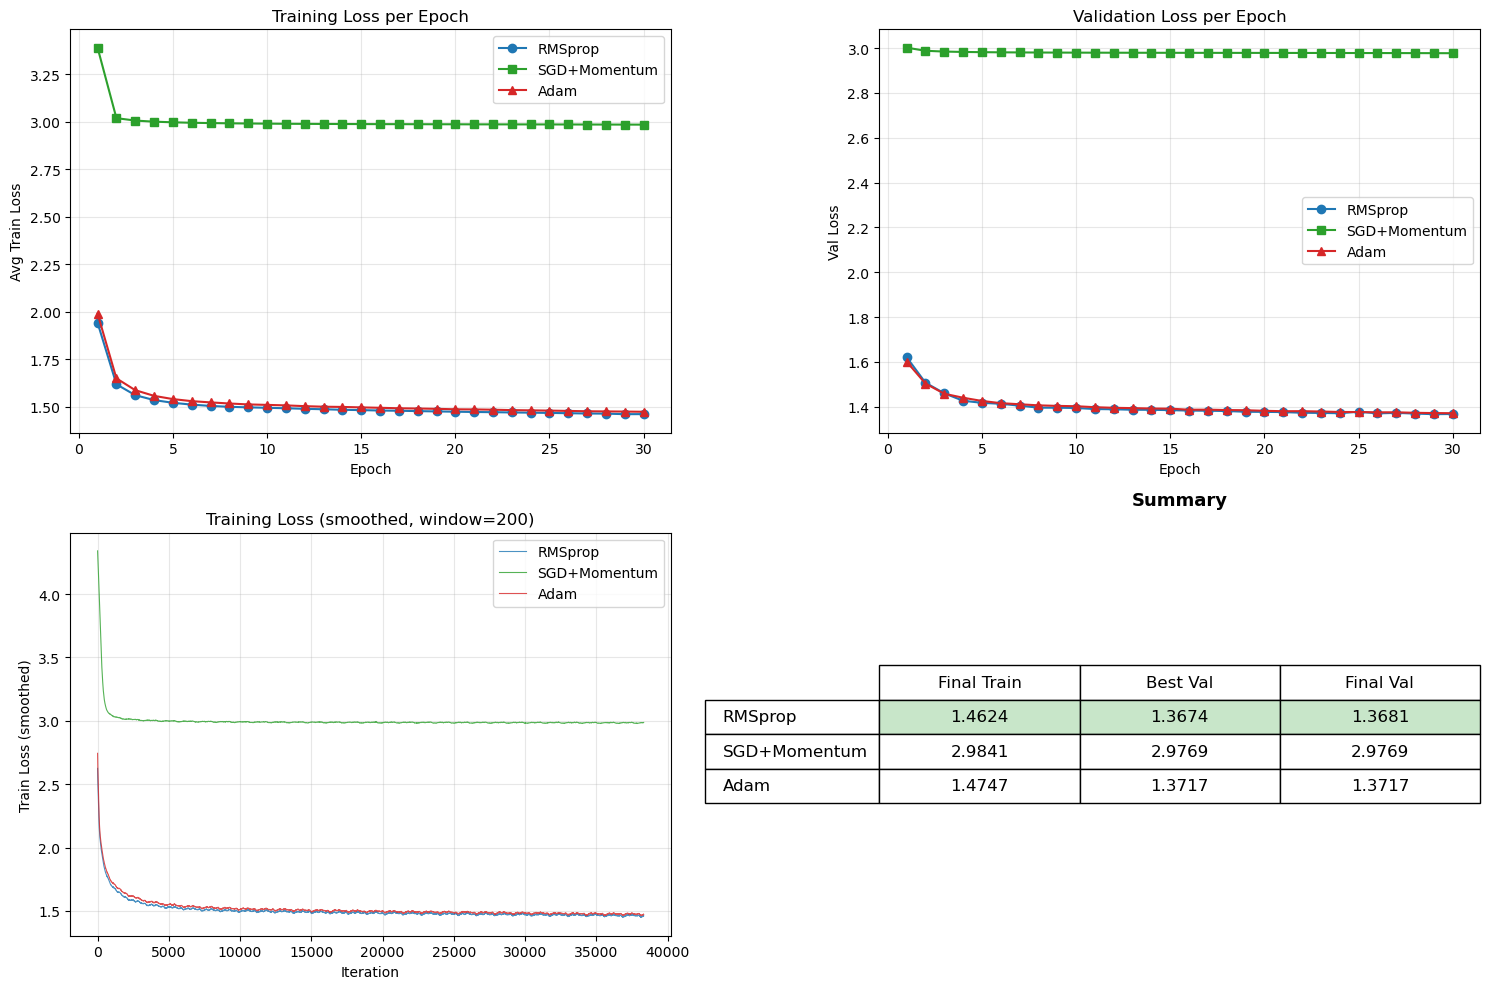

Saved plot to optimizer_comparison.png


In [13]:
# ── Comparison plots ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── 1. Per-epoch training loss ────────────────────────────────────────
ax = axes[0, 0]
epochs_range = range(1, max_epochs + 1)
if rmsprop_epoch_train:
    ax.plot(epochs_range[:len(rmsprop_epoch_train)], rmsprop_epoch_train, 'o-', label='RMSprop', color='tab:blue')
ax.plot(epochs_range[:len(sgd_epoch_train)], sgd_epoch_train, 's-', label='SGD+Momentum', color='tab:green')
ax.plot(epochs_range[:len(adam_epoch_train)], adam_epoch_train, '^-', label='Adam', color='tab:red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Avg Train Loss')
ax.set_title('Training Loss per Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 2. Per-epoch validation loss ──────────────────────────────────────
ax = axes[0, 1]
if rmsprop_epoch_val:
    ax.plot(epochs_range[:len(rmsprop_epoch_val)], rmsprop_epoch_val, 'o-', label='RMSprop', color='tab:blue')
ax.plot(epochs_range[:len(sgd_epoch_val)], sgd_epoch_val, 's-', label='SGD+Momentum', color='tab:green')
ax.plot(epochs_range[:len(adam_epoch_val)], adam_epoch_val, '^-', label='Adam', color='tab:red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Loss')
ax.set_title('Validation Loss per Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3. Smoothed training loss over iterations ────────────────────────
ax = axes[1, 0]
smooth_w = 200
for losses, name, color in [
    (rmsprop_train_losses, 'RMSprop', 'tab:blue'),
    (sgd_train, 'SGD+Momentum', 'tab:green'),
    (adam_train, 'Adam', 'tab:red'),
]:
    if len(losses) >= smooth_w:
        smoothed = np.convolve(losses, np.ones(smooth_w)/smooth_w, mode='valid')
        ax.plot(smoothed, label=name, color=color, linewidth=0.8, alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('Train Loss (smoothed)')
ax.set_title(f'Training Loss (smoothed, window={smooth_w})')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 4. Summary table ─────────────────────────────────────────────────
ax = axes[1, 1]
ax.axis('off')

results = {}
for name, ep_train, ep_val in [
    ('RMSprop', rmsprop_epoch_train, rmsprop_epoch_val),
    ('SGD+Momentum', sgd_epoch_train, sgd_epoch_val),
    ('Adam', adam_epoch_train, adam_epoch_val),
]:
    results[name] = {
        'Final Train': f"{ep_train[-1]:.4f}" if ep_train else "N/A",
        'Best Val': f"{min(ep_val):.4f}" if ep_val else "N/A",
        'Final Val': f"{ep_val[-1]:.4f}" if ep_val else "N/A",
    }

col_labels = ['Final Train', 'Best Val', 'Final Val']
row_labels = list(results.keys())
cell_text = [[results[r][c] for c in col_labels] for r in row_labels]

table = ax.table(cellText=cell_text, rowLabels=row_labels, colLabels=col_labels,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

# Color the best values
for col_idx, col in enumerate(col_labels):
    vals = []
    for r in row_labels:
        v = results[r][col]
        vals.append(float(v) if v != "N/A" else float('inf'))
    best_row = np.argmin(vals)
    table[best_row + 1, col_idx].set_facecolor('#c8e6c9')  # light green

ax.set_title('Summary', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot to optimizer_comparison.png")

In [14]:
# ── Compare generated text from all three optimizers ──────────────────
# Same seed=4869 for all → reproducible and fair comparison
prime = "Sherlock Holmes "
gen_length = 500
temp = 0.7

for name, mdl in [('RMSprop', rmsprop_model), ('SGD+Momentum', sgd_model), ('Adam', adam_model)]:
    print(f"\n{'='*70}")
    print(f"  {name} — temperature={temp}, seed=4869")
    print(f"{'='*70}")
    print(generate(mdl, prime_text=prime, length=gen_length, temperature=temp, seed=4869))


  RMSprop — temperature=0.7, seed=4869
Sherlock Holmes to strange to
     so clace of it one of the engucation that a heart was there out of the opened
     reath clist of a great furriate in the assuse that they dasted him to stand his
     shagp money to the few way that lead in the pranted at the other that the
     conscarious hand, the brack right of his street and the cabling of interest out of
     behind the man his probomess, which I have been seen the prant of a little
     did do not the house of the barker and more way in the irpultied a

  SGD+Momentum — temperature=0.7, seed=4869
Sherlock Holmes tt ssnl   mt r 
heol      te d i eoelse na   e.iutd  aat
tau n he sr " sn  orts eni   r t  pe a 
  eier  t  cdis ns . uach la d eaie  ie  nila  oH   a trrtrwe aadhi he bt  s, i  hhaie   m   gs    
 wtosteat e s a  teaeyl h, i rnl e   
heo ate deeoe  ditehsh m er  
   tenhe  eskhd  odt   ir,     ge     hee i   o tat  t t     m   oW   hbtsh y  s 
shth e b heio ttor.  cn   nnb.rmt  